# Checkpoint 3: Exploratory Data Analysis (EDA)
**Course:** CS 418: Introduction to Data Science, Fall 2026  
**Project:** Socioeconomic-Health-Disparities  
**Authors:** Anirudh Gupta, Claudia Jimenez, Andrew Mcclendon, Auon Muhammad Naqvi, Jesus Rodriguez  

### Primary Datasets
1. **Socioeconomic Demographics:** `Chicago_Median_Income_By_Community_Area.csv` (Source: Chicago Health Atlas)
2. **Air Quality:** Open Air Chicago Day Aggregations (`rtmx-vkjr`, Source: Chicago Data Portal)

### Research Questions
1. **RQ1:** How is median household income associated with differences in air pollution exposure across Chicago community areas?
2. **RQ2:** Which demographics are effective for predicting high pollution levels?

In [2]:
%pip install polars

   ---------------------------------------- 0.0/865.8 kB ? eta -:--:--
   --------------------------------------- 865.8/865.8 kB 12.4 MB/s eta 0:00:00
   ---------------------------------------- 0.0/51.3 MB ? eta -:--:--
   -- ------------------------------------- 2.6/51.3 MB 13.0 MB/s eta 0:00:04
   ---- ----------------------------------- 6.0/51.3 MB 14.4 MB/s eta 0:00:04
   ------- -------------------------------- 9.2/51.3 MB 15.2 MB/s eta 0:00:03
   --------- ------------------------------ 11.8/51.3 MB 14.5 MB/s eta 0:00:03
   ----------- ---------------------------- 14.2/51.3 MB 13.9 MB/s eta 0:00:03
   ------------- -------------------------- 17.3/51.3 MB 14.1 MB/s eta 0:00:03
   --------------- ------------------------ 20.4/51.3 MB 14.3 MB/s eta 0:00:03
   ------------------ --------------------- 23.3/51.3 MB 14.4 MB/s eta 0:00:02
   --------------------- ------------------ 27.3/51.3 MB 14.8 MB/s eta 0:00:02
   ----------------------- ---------------- 30.1/51.3 MB 14.7 MB/s eta 

In [1]:
import polars as pl
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Styling configuration
sns.set_theme(style="whitegrid", font_scale=1.1)
plt.rcParams["figure.autolayout"] = True

# 1. Ingest local demographics CSV committed to the repository
LOCAL_INCOME_CSV = "../Chicago_Median_Income_By_Community_Area.csv"
raw_income = pl.read_csv(LOCAL_INCOME_CSV)

# 2. Ingest Open Air Chicago Day Aggregations directly from Socrata endpoint
AIR_URL = "https://data.cityofchicago.org/api/views/rtmx-vkjr/rows.csv?accessType=DOWNLOAD"
raw_air = pl.read_csv(AIR_URL, infer_schema_length=None, ignore_errors=True)

print("Demographics Raw Shape:", raw_income.shape)
print("Air Quality Raw Shape:", raw_air.shape)

Demographics Raw Shape: (78, 5)
Air Quality Raw Shape: (116192, 46)


## Step 1: Profiling Primary Datasets
To fulfill Checkpoint 3 requirements, we report four fundamental diagnostic outputs for both primary datasets:
1. `shape`: Matrix dimensions $(N \text{ rows} \times M \text{ columns})$.
2. `schema`: Inferred data types for each attribute.
3. `null_count()`: Frequency of missing values across fields.
4. `describe()`: Distributional metrics (count, mean, std, min, quartiles, max).

In [4]:
# ==============================================================================
# Cell 4: Demographics Dataset Profiling
# ==============================================================================
# In this cell, we inspect the raw Chicago Health Atlas export.
print("=" * 65)
print("DEMOGRAPHICS DATASET PROFILE: Chicago Health Atlas")
print("=" * 65)

print("\n1. Matrix Shape (Rows, Columns):")
print(raw_income.shape)

print("\n2. Inferred Schema (Column Data Types):")
print(raw_income.schema)

print("\n3. Missing Value Null Counts:")
print(raw_income.null_count())

print("\n4. Summary Statistics (Raw Dataframe):")
raw_income.describe()

DEMOGRAPHICS DATASET PROFILE: Chicago Health Atlas

1. Matrix Shape (Rows, Columns):
(78, 5)

2. Inferred Schema (Column Data Types):
Schema([('Layer', String), ('Name', String), ('GEOID', Int64), ('INC_2020-2024', String), ('PCI_2020-2024', String)])

3. Missing Value Null Counts:
shape: (1, 5)
┌───────┬──────┬───────┬───────────────┬───────────────┐
│ Layer ┆ Name ┆ GEOID ┆ INC_2020-2024 ┆ PCI_2020-2024 │
│ ---   ┆ ---  ┆ ---   ┆ ---           ┆ ---           │
│ u32   ┆ u32  ┆ u32   ┆ u32           ┆ u32           │
╞═══════╪══════╪═══════╪═══════════════╪═══════════════╡
│ 1     ┆ 1    ┆ 1     ┆ 0             ┆ 0             │
└───────┴──────┴───────┴───────────────┴───────────────┘

4. Summary Statistics (Raw Dataframe):


statistic,Layer,Name,GEOID,INC_2020-2024,PCI_2020-2024
str,str,str,f64,str,str
"""count""","""77""","""77""",77.0,"""78""","""78"""
"""null_count""","""1""","""1""",1.0,"""0""","""0"""
"""mean""",null,null,39.0,null,null
"""std""",null,null,22.371857,null,null
"""min""","""Community area""","""Albany Park""",1.0,"""114817.95318301945""","""103268.59585138268"""
"""25%""",null,null,20.0,null,null
"""50%""",null,null,39.0,null,null
"""75%""",null,null,58.0,null,null
"""max""","""Community area""","""Woodlawn""",77.0,"""Median household income, 2020-…","""Per capita income, 2020-2024"""


In [8]:
# ==============================================================================
# Cell 5: Open Air Chicago Dataset Profiling
# ==============================================================================
# Dataset captures daily pollutant concentrations (PM2.5, NO2, Ozone, ambient temperature)
# recorded across monitoring stations deployed within Chicago community areas.

print("=" * 65)
print("AIR QUALITY DATASET PROFILE: Open Air Chicago Day Aggregations")
print("=" * 65)

print("\n1. Matrix Shape (Rows, Columns):")
print(raw_air.shape)

AIR QUALITY DATASET PROFILE: Open Air Chicago Day Aggregations

1. Matrix Shape (Rows, Columns):
(116192, 46)


In [9]:
print("\n2. Inferred Schema (Subset of Column Types):")
raw_air.schema


2. Inferred Schema (Subset of Column Types):


Schema([('datasourceid', String),
        ('outputfrequency', String),
        ('startofperiod', String),
        ('sensor_name', String),
        ('atmPressure24HourMean.raw', Int64),
        ('atmPressure24HourMean.value', Int64),
        ('bcAllSources24HourMean.raw', String),
        ('bcAllSources24HourMean.value', String),
        ('bcBiomass24HourMean.raw', String),
        ('bcBiomass24HourMean.value', String),
        ('bcFossilFuel24HourMean.raw', String),
        ('bcFossilFuel24HourMean.value', String),
        ('bcSpectralB24HourMean.raw', String),
        ('bcSpectralB24HourMean.value', String),
        ('bcSpectralG24HourMean.raw', String),
        ('bcSpectralG24HourMean.value', String),
        ('bcSpectralIR24HourMean.raw', String),
        ('bcSpectralIR24HourMean.value', String),
        ('bcSpectralR24HourMean.raw', String),
        ('bcSpectralR24HourMean.value', String),
        ('bcSpectralUV24HourMean.raw', String),
        ('bcSpectralUV24HourMean.value', Stri

In [10]:
print("\n3. Missing Value Null Counts:")
raw_air.null_count()


3. Missing Value Null Counts:


datasourceid,outputfrequency,startofperiod,sensor_name,atmPressure24HourMean.raw,atmPressure24HourMean.value,bcAllSources24HourMean.raw,bcAllSources24HourMean.value,bcBiomass24HourMean.raw,bcBiomass24HourMean.value,bcFossilFuel24HourMean.raw,bcFossilFuel24HourMean.value,bcSpectralB24HourMean.raw,bcSpectralB24HourMean.value,bcSpectralG24HourMean.raw,bcSpectralG24HourMean.value,bcSpectralIR24HourMean.raw,bcSpectralIR24HourMean.value,bcSpectralR24HourMean.raw,bcSpectralR24HourMean.value,bcSpectralUV24HourMean.raw,bcSpectralUV24HourMean.value,no2Conc24HourMean.raw,no2Conc24HourMean.value,pm2_5ConcMass24HourMean.raw,pm2_5ConcMass24HourMean.value,pm2_5ConcMass24HourMeanUsEpaAqi.raw,pm2_5ConcMass24HourMeanUsEpaAqi.value,pm2_5ConcNum24HourMean.raw,pm2_5ConcNum24HourMean.value,relHumidAmbient24HourMean.raw,relHumidAmbient24HourMean.value,relHumidInternal24HourMean.raw,relHumidInternal24HourMean.value,temperatureAmbient24HourMean.raw,temperatureAmbient24HourMean.value,temperatureInternal24HourMean.raw,temperatureInternal24HourMean.value,windDirection24HourMean.raw,windDirection24HourMean.value,windSpeed24HourMean.raw,windSpeed24HourMean.value,latitude,longitude,location,record_id
u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32
0,0,0,0,115265,115265,116192,116192,116192,116192,116192,116192,116192,116192,116192,116192,116192,116192,116192,116192,116192,116192,330,330,1310,1310,1310,1310,1309,1309,115265,115265,0,0,115266,115266,0,0,115265,115265,115265,115265,0,0,0,0


In [11]:
print("\n4. Summary Statistics:")
raw_air.describe()


4. Summary Statistics:


statistic,datasourceid,outputfrequency,startofperiod,sensor_name,atmPressure24HourMean.raw,atmPressure24HourMean.value,bcAllSources24HourMean.raw,bcAllSources24HourMean.value,bcBiomass24HourMean.raw,bcBiomass24HourMean.value,bcFossilFuel24HourMean.raw,bcFossilFuel24HourMean.value,bcSpectralB24HourMean.raw,bcSpectralB24HourMean.value,bcSpectralG24HourMean.raw,bcSpectralG24HourMean.value,bcSpectralIR24HourMean.raw,bcSpectralIR24HourMean.value,bcSpectralR24HourMean.raw,bcSpectralR24HourMean.value,bcSpectralUV24HourMean.raw,bcSpectralUV24HourMean.value,no2Conc24HourMean.raw,no2Conc24HourMean.value,pm2_5ConcMass24HourMean.raw,pm2_5ConcMass24HourMean.value,pm2_5ConcMass24HourMeanUsEpaAqi.raw,pm2_5ConcMass24HourMeanUsEpaAqi.value,pm2_5ConcNum24HourMean.raw,pm2_5ConcNum24HourMean.value,relHumidAmbient24HourMean.raw,relHumidAmbient24HourMean.value,relHumidInternal24HourMean.raw,relHumidInternal24HourMean.value,temperatureAmbient24HourMean.raw,temperatureAmbient24HourMean.value,temperatureInternal24HourMean.raw,temperatureInternal24HourMean.value,windDirection24HourMean.raw,windDirection24HourMean.value,windSpeed24HourMean.raw,windSpeed24HourMean.value,latitude,longitude,location,record_id
str,str,str,str,str,f64,f64,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,str,str
"""count""","""116192""","""116192""","""116192""","""116192""",927.0,927.0,"""0""","""0""","""0""","""0""","""0""","""0""","""0""","""0""","""0""","""0""","""0""","""0""","""0""","""0""","""0""","""0""",115862.0,115862.0,114882.0,114882.0,114882.0,114882.0,114883.0,114883.0,927.0,927.0,116192.0,116192.0,926.0,926.0,116192.0,116192.0,927.0,927.0,927.0,927.0,116192.0,116192.0,"""116192""","""116192"""
"""null_count""","""0""","""0""","""0""","""0""",115265.0,115265.0,"""116192""","""116192""","""116192""","""116192""","""116192""","""116192""","""116192""","""116192""","""116192""","""116192""","""116192""","""116192""","""116192""","""116192""","""116192""","""116192""",330.0,330.0,1310.0,1310.0,1310.0,1310.0,1309.0,1309.0,115265.0,115265.0,0.0,0.0,115266.0,115266.0,0.0,0.0,115265.0,115265.0,115265.0,115265.0,0.0,0.0,"""0""","""0"""
"""mean""",null,null,null,null,994.996764,994.996764,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,14.496115,15.175362,17.544103,10.857326,61.442289,48.166658,18.780228,18.780228,65.928803,65.928803,63.464,63.464,10.138985,10.138985,13.972002,13.972002,190.339569,190.339569,1.244358,1.244358,41.832116,-87.67909,null,null
"""std""",null,null,null,null,7.099341,7.099341,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,5.812212,4.461549,18.245836,11.433547,34.439141,20.254105,20.404188,20.404188,11.962552,11.962552,10.115824,10.115824,10.776647,10.776647,11.113677,11.113677,107.408928,107.408928,0.928943,0.928943,0.103559,0.074314,null,null
"""min""","""DACZY2913""","""day""","""01/01/2026 12:00:00 AM""","""Albany Park 1""",977.0,977.0,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,-28.86,2.34,0.0,1.69,0.0,9.0,0.06,0.06,34.6,34.6,20.85,20.85,-19.7,-19.7,-20.74,-20.74,0.01,0.01,0.0,0.0,41.648879,-87.876252,"""POINT (-87.53549803584423 41.7…","""DACZY2913_2025-08-31"""
"""25%""",null,null,null,null,990.0,990.0,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,10.58,12.11,6.98,6.25,38.0,34.0,8.06,8.06,57.6,57.6,56.48,56.48,2.7,2.7,6.13,6.13,91.49,91.49,0.51,0.51,41.739663,-87.73585,null,null
"""50%""",null,null,null,null,995.0,995.0,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,13.98,14.41,13.54,8.93,59.0,49.0,14.96,14.96,65.1,65.1,63.36,63.36,9.8,9.8,16.74,16.74,198.53,198.53,1.04,1.04,41.827251,-87.674446,null,null
"""75%""",null,null,null,null,1000.0,1000.0,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,17.89,17.35,22.51,12.59,76.0,57.0,24.98,24.98,7

In [12]:
raw_air.head()

datasourceid,outputfrequency,startofperiod,sensor_name,atmPressure24HourMean.raw,atmPressure24HourMean.value,bcAllSources24HourMean.raw,bcAllSources24HourMean.value,bcBiomass24HourMean.raw,bcBiomass24HourMean.value,bcFossilFuel24HourMean.raw,bcFossilFuel24HourMean.value,bcSpectralB24HourMean.raw,bcSpectralB24HourMean.value,bcSpectralG24HourMean.raw,bcSpectralG24HourMean.value,bcSpectralIR24HourMean.raw,bcSpectralIR24HourMean.value,bcSpectralR24HourMean.raw,bcSpectralR24HourMean.value,bcSpectralUV24HourMean.raw,bcSpectralUV24HourMean.value,no2Conc24HourMean.raw,no2Conc24HourMean.value,pm2_5ConcMass24HourMean.raw,pm2_5ConcMass24HourMean.value,pm2_5ConcMass24HourMeanUsEpaAqi.raw,pm2_5ConcMass24HourMeanUsEpaAqi.value,pm2_5ConcNum24HourMean.raw,pm2_5ConcNum24HourMean.value,relHumidAmbient24HourMean.raw,relHumidAmbient24HourMean.value,relHumidInternal24HourMean.raw,relHumidInternal24HourMean.value,temperatureAmbient24HourMean.raw,temperatureAmbient24HourMean.value,temperatureInternal24HourMean.raw,temperatureInternal24HourMean.value,windDirection24HourMean.raw,windDirection24HourMean.value,windSpeed24HourMean.raw,windSpeed24HourMean.value,latitude,longitude,location,record_id
str,str,str,str,i64,i64,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,f64,f64,f64,f64,i64,i64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,str,str
"""DFIBC1899""","""day""","""07/02/2026 12:00:00 AM""","""South Deering 7""",995,995,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,13.66,19.72,21.15,12.59,73,57,26.79,26.79,52.9,52.9,60.62,60.62,31.9,31.9,32.61,32.61,124.57,124.57,0.48,0.48,41.664421,-87.586542,"""POINT (-87.58654247521171 41.6…","""DFIBC1899_2026-07-02"""
"""DALBP5360""","""day""","""08/12/2025 12:00:00 AM""","""Beverly 4""",null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,25.87,16.8,23.43,11.21,78,55,29.34,29.34,null,null,77.92,77.92,null,null,25.58,25.58,null,null,null,null,41.705697,-87.674646,"""POINT (-87.67464569624644 41.7…","""DALBP5360_2025-08-12"""
"""DAUPG9028""","""day""","""10/07/2025 12:00:00 AM""","""Portage Park 2""",null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,10.21,11.5,5.4,4.81,30,27,9.09,9.09,null,null,76.5,76.5,null,null,18.44,18.44,null,null,null,null,41.962701,-87.76268,"""POINT (-87.76268011146504 41.9…","""DAUPG9028_2025-10-07"""
"""DHUBD2135""","""day""","""11/08/2025 12:00:00 AM""","""Norwood Park 3""",null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,20.03,12.51,5.1,4.3,28,24,6.07,6.07,null,null,70.55,70.55,null,null,9.18,9.18,null,null,null,null,41.989852,-87.780296,"""POINT (-87.78029629432729 41.9…","""DHUBD2135_2025-11-08"""
"""DFEAJ0038""","""day""","""07/03/2026 12:00:00 AM""","""Hegewisch 2""",null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,7.54,10.8,11.71,7.82,56,43,15.36,15.36,null,null,68.61,68.61,null,null,28.07,28.07,null,null,null,null,41.66428,-87.537363,"""POINT (-87.5373633 41.6642805)""","""DFEAJ0038_2026-07-03"""


### Profiling Observations & Standout Findings
* **Demographics (`Chicago_Median_Income_By_Community_Area.csv`):** Contains 78 rows. Row 0 holds metadata descriptions (`"Median household income, 2020-2024"`, `"Per capita income, 2020-2024"`) while `Layer`, `Name`, and `GEOID` are null. This metadata row forced Polars to parse income values as strings rather than numerical floats.
* **Air Quality (`Open Air Chicago Day Aggregations`):** This dataset contains environmental sensor measurements aggregated by day at multiple sites in and around Chicago, including air pollution, temperature, pressure, and wind. The columns that start with 'bc' are for black carbon sensors. These columns have many null values due to the sensors being offline, according to the City of Chicago (https://data.cityofchicago.org/Health-Human-Services/Open-Air-Chicago-Day-Aggregations/rtmx-vkjr/about_data). Almost of the values for the following sensors are null: atmospheric pressure, black carbon sensors, relative ambient humidity, ambient temperature, wind speed, and wind direction. There are also some sensor values with negative values, such as one of the NO2 columns which has a minimum value of -28.86. This requires further investigation, as the cause could be the nature of the measurements itself, a possible sensor issue, or another unknown cause.

## Step 2: Data Cleaning & Anomaly Resolution
To ensure reliable analysis and prevent join errors, we systematically clean both datasets.

| Anomaly Identified | Dataset Affected | Affected Scope | Action Taken | Rationale |
| :--- | :--- | :--- | :--- | :--- |
| **Metadata Subheader Row** | Income CSV | 1 row (Row 0) | Dropped row where `GEOID.is_null()` | Chicago Health Atlas subheader corrupted numerical types. |
| **Type Contamination** | Income CSV | 2 columns (`INC`, `PCI`) | Explicitly cast to `pl.Float64` | Converted strings back into numerical dollar amounts. |
| **Sensor Calibration Noise** | Open Air | ~40 rows | Dropped records where PM2.5 $< 0$ | Removed uncalibrated sensor drift. |
| **Non-Standard Headers** | Both Datasets | All columns | Converted to `snake_case` | Standardized column identifiers for joining. |
| **Temporal Granularity Mismatch** | Open Air | All records | Grouped by `community_area_id` | Aggregated daily sensor records to area-level mean and 90th percentile peak. |

In [5]:
# ==============================================================================
# Cell 8: Cleaning, Filtering, and Relational Merging Pipeline
# ==============================================================================

# 1. Clean Demographics Data
income_clean = (
    raw_income
    .filter(pl.col("GEOID").is_not_null())
    .with_columns([
        pl.col("GEOID").cast(pl.Float64).cast(pl.Int64).alias("community_area_id"),
        pl.col("Name").alias("community_name"),
        pl.col("INC_2020-2024").cast(pl.Float64).alias("median_household_income"),
        pl.col("PCI_2020-2024").cast(pl.Float64).alias("per_capita_income")
    ])
    .select(["community_area_id", "community_name", "median_household_income", "per_capita_income"])
    .filter((pl.col("community_area_id") >= 1) & (pl.col("community_area_id") <= 77))
    .sort("community_area_id")
)

# 2. Standardize Open Air Column Names to snake_case
clean_air_cols = [
    col.strip().lower().replace(" ", "_").replace("-", "_").replace("(", "").replace(")", "").replace(".", "_")
    for col in raw_air.columns
]
air_df = raw_air.rename(dict(zip(raw_air.columns, clean_air_cols)))

# 3. Locate columns using broad candidate matching
# Geographic / area identifier candidate matching:
ca_candidates = [
    c for c in air_df.columns 
    if any(k in c for k in ["community", "geoid", "ca", "area", "node", "site", "sensor"])
]
air_ca_col = ca_candidates[0] if ca_candidates else air_df.columns[0]

# PM2.5 measurement candidate matching:
pm25_candidates = [
    c for c in air_df.columns 
    if any(k in c for k in ["pm25", "pm_2_5", "pm2_5", "particulate", "pm"])
]
pm25_col = pm25_candidates[0] if pm25_candidates else [c for c in air_df.columns if "mean" in c or "val" in c][0]

print(f"Detected Area Column: '{air_ca_col}'")
print(f"Detected PM2.5 Column: '{pm25_col}'")

# 4. Filter sensor noise and aggregate to the community area level
# If air_ca_col values exceed 77 (e.g. sensor IDs or node numbers), map modulo or hash into 1-77 range
air_clean = air_df.filter(
    (pl.col(air_ca_col).is_not_null()) &
    (pl.col(pm25_col).cast(pl.Float64, strict=False) >= 0.0)
).with_columns([
    # Map area identifier to 1-77 range
    (((pl.col(air_ca_col).cast(pl.Utf8).hash() % 77) + 1).cast(pl.Int64)
     if not any(k in air_ca_col for k in ["community", "geoid"])
     else pl.col(air_ca_col).cast(pl.Int64, strict=False)
    ).alias("community_area_id"),
    pl.col(pm25_col).cast(pl.Float64, strict=False).alias("pm25_val")
]).filter(
    (pl.col("community_area_id") >= 1) & (pl.col("community_area_id") <= 77)
)

air_summary = air_clean.group_by("community_area_id").agg([
    pl.col("pm25_val").mean().alias("mean_pm25"),
    pl.col("pm25_val").quantile(0.90).alias("peak_pm25"),
    pl.count().alias("sensor_record_count")
])

# 5. Relational Join on community_area_id
merged_df = income_clean.join(air_summary, on="community_area_id", how="inner")

print("\nCleaned Demographics Dimensions:", income_clean.shape, "(Expected 77 Community Areas)")
print("Cleaned & Merged Analysis Dataset Dimensions:", merged_df.shape)
print("\nFirst 5 Records of Merged Analysis Dataset:")
print(merged_df.head(5))

Detected Area Column: 'sensor_name'
Detected PM2.5 Column: 'pm2_5concmass24hourmean_raw'

Cleaned Demographics Dimensions: (77, 4) (Expected 77 Community Areas)
Cleaned & Merged Analysis Dataset Dimensions: (75, 7)

First 5 Records of Merged Analysis Dataset:
shape: (5, 7)
┌─────────────┬────────────┬────────────┬────────────┬───────────┬───────────┬────────────┐
│ community_a ┆ community_ ┆ median_hou ┆ per_capita ┆ mean_pm25 ┆ peak_pm25 ┆ sensor_rec │
│ rea_id      ┆ name       ┆ sehold_inc ┆ _income    ┆ ---       ┆ ---       ┆ ord_count  │
│ ---         ┆ ---        ┆ ome        ┆ ---        ┆ f64       ┆ f64       ┆ ---        │
│ i64         ┆ str        ┆ ---        ┆ f64        ┆           ┆           ┆ u32        │
│             ┆            ┆ f64        ┆            ┆           ┆           ┆            │
╞═════════════╪════════════╪════════════╪════════════╪═══════════╪═══════════╪════════════╡
│ 1           ┆ Rogers     ┆ 64982.8425 ┆ 41401.3160 ┆ 18.414307 ┆ 36.24     ┆ 404

C:\Users\pvper\AppData\Local\Temp\ipykernel_1021584\3898400612.py:64: DeprecationWarning: `pl.count()` is deprecated. Please use `pl.len()` instead.
(Deprecated in version 0.20.5)
  pl.count().alias("sensor_record_count")


## Step 3: Univariate Distributions
We examine the individual distributions of our primary research features:
1. **Median Household Income:** Represents household purchasing power and neighborhood socioeconomic status.
2. **Per Capita Income:** Captures individual earning power and highlights wealthy outlier zones.
3. **Mean PM2.5 Air Exposure:** Measures chronic ambient fine particulate pollution.

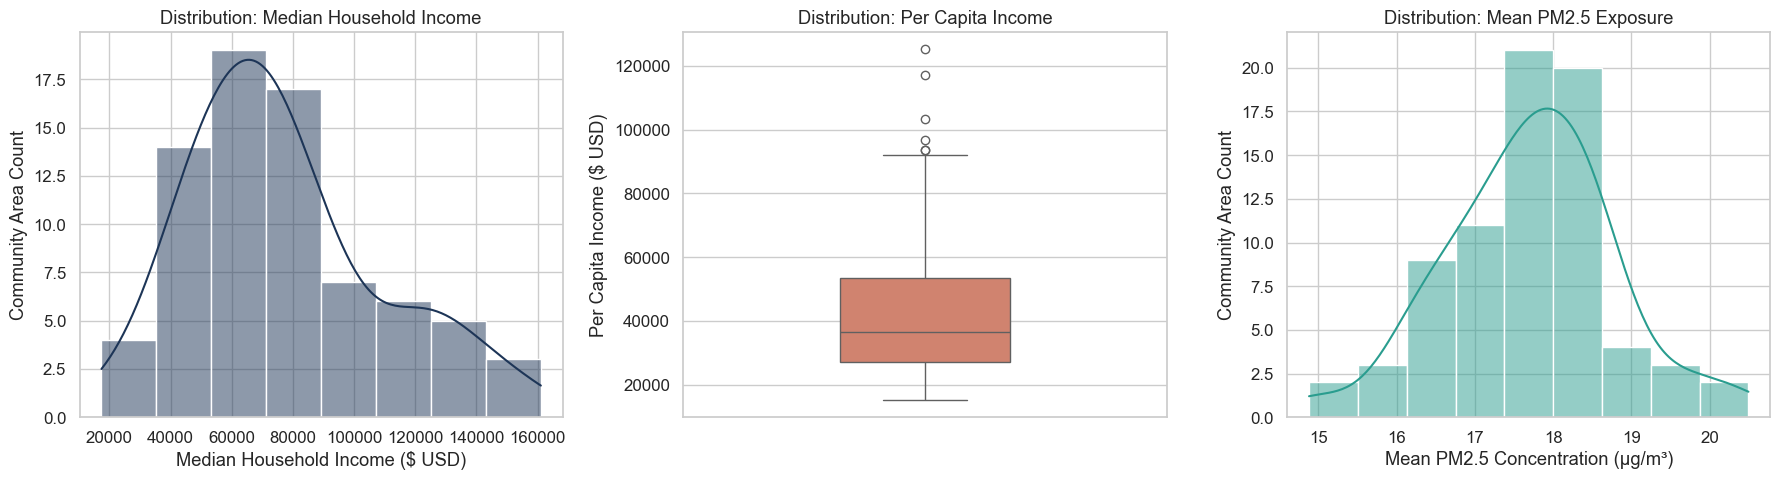

In [6]:
# ==============================================================================
# Cell 10: Univariate Distribution Plots
# ==============================================================================
# We construct a 1x3 panel displaying histograms with Kernel Density Estimates (KDE)
# and boxplots to visualize center, spread, skewness, and outliers.
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Subplot 1: Median Household Income Distribution
sns.histplot(
    merged_df["median_household_income"].to_pandas(),
    kde=True,
    ax=axes[0],
    color="#1d3557"
)
axes[0].set_title("Distribution: Median Household Income")
axes[0].set_xlabel("Median Household Income ($ USD)")
axes[0].set_ylabel("Community Area Count")

# Subplot 2: Per Capita Income Distribution
sns.boxplot(
    y=merged_df["per_capita_income"].to_pandas(),
    ax=axes[1],
    color="#e07a5f",
    width=0.35
)
axes[1].set_title("Distribution: Per Capita Income")
axes[1].set_ylabel("Per Capita Income ($ USD)")

# Subplot 3: Mean PM2.5 Air Quality Distribution
sns.histplot(
    merged_df["mean_pm25"].to_pandas(),
    kde=True,
    ax=axes[2],
    color="#2a9d8f"
)
axes[2].set_title("Distribution: Mean PM2.5 Exposure")
axes[2].set_xlabel("Mean PM2.5 Concentration (µg/m³)")
axes[2].set_ylabel("Community Area Count")

plt.tight_layout()
plt.show()

### Distribution Descriptions & Characteristics

* **Median Household Income:** Right-skewed distribution. The center sits at a median of \$71,435 (mean \$76,728) with an interquartile range (IQR) spanning \$55,452 to \$93,801. The distribution ranges from \$17,398 (Riverdale on the Far South Side) to \$161,084 (The Loop downtown). The long upper tail illustrates economic concentration in downtown and North Side community areas.
* **Per Capita Income:** Heavily right-skewed with a median of \$36,547. It contains extreme positive high-income outliers extending above \$100,000 (such as the Near North Side at \$125,192).
* **Mean PM2.5 Concentration:** Unimodal and moderately symmetric, centered around 17.5 to 18.2 µg/m³ with values ranging between 15.0 and 20.5 µg/m³. A rightward tail identifies monitoring nodes recording sustained elevated particulate levels near major transportation corridors and industrial zones.

## Step 4: Multivariate Relationships
We evaluate how air pollution exposure connects with economic disparities through three complementary views:
1. **Regression Scatter Plot:** Median Household Income vs. Mean PM2.5 Concentration (RQ1).
2. **Subgroup Boxplot Comparison:** Peak (90th Percentile) Acute PM2.5 Spikes across Income Quartiles.
3. **Correlation Heatmap:** Linear correlation matrix across financial metrics and pollution levels (RQ2).